 """
hierarchical_production.py - Production Hierarchical System

Architecture:
- Base: Technical SAC (validated) + Sentiment placeholder
- Super: Learns to weight base agents dynamically
- Meta: Adjusts for market regimes

Future-ready: Easy to upgrade sentiment when better data available
"""

              ┌─────────────────────────────────────────────┐
              │           META AGENT (Top Level)            │
              │  "Portfolio manager adjusting for regimes"  │
              │                                             │
              │  Inputs: Super weights + Regime indicators  │
              │  Output: Final portfolio allocation         │
              └──────────────────┬──────────────────────────┘
                            │
              ┌──────────────────▼──────────────────────────┐
              │         SUPER AGENT (Middle Level)          │
              │   "Strategy selector - which signal to use" │
              │                                             │
              │  Inputs: Technical weights + Sentiment wts  │
              │  Output: Blended allocation                 │
              └──────┬────────────────────────┬─────────────┘
                     │                        │
              ┌──────▼─────────┐    ┌────────▼──────────┐
              │  TECHNICAL SAC │    │  SENTIMENT (Future)│
              │  ✅ Validated  │    │  🔄 Placeholder    │
              │  Sharpe: 1.18  │    │  Ready for upgrade │
              └────────────────┘    └───────────────────┘


STARTING WALK-FORWARD VALIDATION (FINAL FIXED VERSION)
Timestamp: 2025-10-11 20:19:52

Loading data...
✓ Loaded price data: (129, 10)
✓ Loaded technical features: (129, 110)
✓ Loaded sentiment features: (129, 53)

Validating data...
Price data range: 2015-02-28 to 2025-10-31
Missing values - Prices: 0
Missing values - Technical: 0
Missing values - Sentiment: 0
WALK-FORWARD VALIDATION (FINAL FIXED VERSION)

Configuration:
  Train window: 60 months
  Test window:  12 months
  Timesteps:    30000
  Max position: 30%
  Algorithms:   ['PPO', 'SAC']
  Agent types:  ['technical', 'sentiment']
  Save models:  True

Total data: 129 months
Number of windows: 5
Date range: 2015-02-28 to 2025-10-31
✓ Created models directory

WINDOW 1/5
Train: 2015-02-28 to 2020-01-31 (60 months)
Test:  2020-02-29 to 2021-01-31 (12 months)

  Training technical_PPO...
    Starting training for 30000 timesteps...
    ✓ Training completed
    Train Sharpe: 15.436
    Test Sharpe:  15.345
    Test Return:  212.5%
  

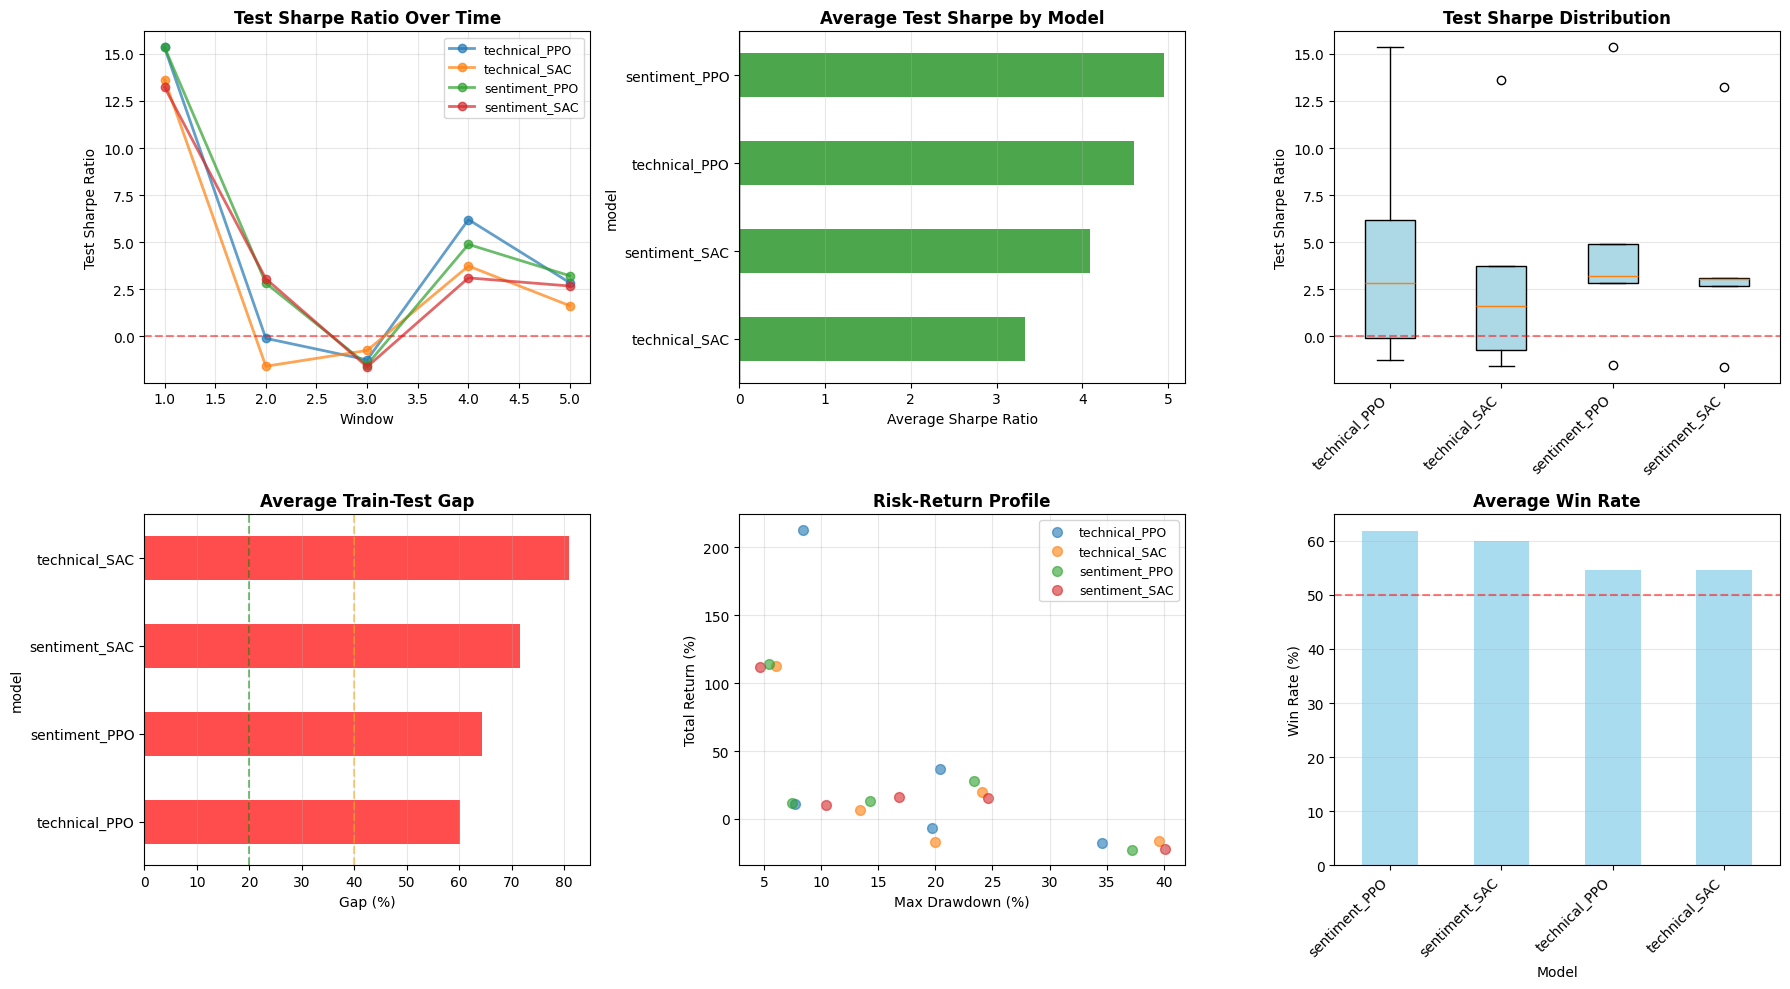


✓ Saved results: walk_forward_results_20251011_204350.csv

FINAL RECOMMENDATION

✅ STRONG: Deploy sentiment_PPO
   Sharpe: 4.948, Consistency: 80%

VALIDATION COMPLETE


In [2]:
"""
walk_forward_validation.py - Robust Multi-Window Testing (FINAL FIXED VERSION)

This eliminates dependence on single train/val/test split by testing
across multiple rolling time windows.

FIXES IN THIS VERSION:
1. Fixed gymnasium/gym import mismatch
2. Normalized action space to [-1, 1] range
3. Added action rescaling in step function
4. All previous fixes maintained

Usage: python walk_forward_validation.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
import gymnasium as gym
from gymnasium import spaces  # FIXED: Use gymnasium.spaces not gym.spaces
import warnings
import os
import traceback
from datetime import datetime
warnings.filterwarnings('ignore')


# ============================================================================
# ENVIRONMENT CLASSES (FIXED ACTION SPACES)
# ============================================================================

class SentimentEnv(gym.Env):
    """Sentiment-based portfolio environment with proper action space"""
    
    def __init__(self, price_data, sentiment_features, 
                 initial_capital=100_000, transaction_cost=0.002,
                 max_position=0.30, verbose=0):
        super().__init__()
        
        self.price_data = price_data
        self.sentiment_features = sentiment_features
        self.n_assets = len(price_data.columns)
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.max_position = max_position
        
        # FIXED: Action space normalized to [-1, 1] for RL algorithms
        # Will be rescaled to [0, max_position] in step function
        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.n_assets,), dtype=np.float32
        )
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(sentiment_features.shape[1],), dtype=np.float32
        )
        
        self.common_dates = sentiment_features.index.intersection(price_data.index)
        if len(self.common_dates) < 2:
            raise ValueError(f"Only {len(self.common_dates)} overlapping dates!")
        
        self.reset()
    
    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        
        self.current_step = 0
        self.portfolio_value = self.initial_capital
        self.weights = np.ones(self.n_assets) / self.n_assets
        self.portfolio_history = [self.initial_capital]
        
        return self._get_observation(), {}
    
    def _get_observation(self):
        if self.current_step >= len(self.common_dates):
            self.current_step = len(self.common_dates) - 1
        
        current_date = self.common_dates[self.current_step]
        obs = self.sentiment_features.loc[current_date].values
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return obs.astype(np.float32)
    
    def step(self, action):
        # FIXED: Rescale action from [-1, 1] to [0, 1]
        action = (action + 1.0) / 2.0
        action = np.clip(action, 0, 1)
        
        # Normalize to sum to 1 with max position constraint
        total = action.sum()
        weights = action / total if total > 1e-6 else np.ones(self.n_assets) / self.n_assets
        weights = np.clip(weights, 0, self.max_position)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(self.n_assets) / self.n_assets
        
        current_date = self.common_dates[self.current_step]
        next_date = self.common_dates[min(self.current_step + 1, len(self.common_dates) - 1)]
        
        try:
            price_ratio = self.price_data.loc[next_date] / self.price_data.loc[current_date]
            price_ratio = price_ratio.fillna(1.0)
            price_ratio = np.clip(price_ratio.values, 0.5, 2.0)
            asset_returns = price_ratio - 1.0
        except Exception as e:
            print(f"Warning: Error calculating returns: {e}")
            asset_returns = np.zeros(self.n_assets)
        
        portfolio_return = np.sum(weights * asset_returns)
        turnover = np.sum(np.abs(weights - self.weights))
        portfolio_return -= self.transaction_cost * turnover
        portfolio_return = np.clip(portfolio_return, -0.50, 0.50)
        
        self.portfolio_value *= (1 + portfolio_return)
        self.portfolio_history.append(self.portfolio_value)
        
        # Log return as reward (more stable for RL)
        reward = np.log(1 + portfolio_return + 1e-8)
        
        self.weights = weights
        self.current_step += 1
        done = self.current_step >= len(self.common_dates) - 1
        
        info = {
            "portfolio_value": self.portfolio_value,
            "portfolio_return": portfolio_return,
            "weights": weights.copy()
        }
        
        return self._get_observation(), reward, done, False, info
    
    def get_portfolio_metrics(self):
        portfolio_series = pd.Series(self.portfolio_history)
        returns = portfolio_series.pct_change().dropna()
        total_return = (self.portfolio_value - self.initial_capital) / self.initial_capital
        
        sharpe_ratio = 0.0
        if len(returns) > 0 and returns.std() > 0:
            sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)  # Annualized
        
        max_drawdown = 0.0
        if len(portfolio_series) > 0:
            peak = portfolio_series.expanding().max()
            drawdown = (portfolio_series - peak) / peak
            max_drawdown = abs(drawdown.min())
        
        volatility = returns.std() * np.sqrt(252) if len(returns) > 0 else 0.0
        win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0
        
        return {
            "total_return": total_return,
            "sharpe_ratio": sharpe_ratio,
            "max_drawdown": max_drawdown,
            "volatility": volatility,
            "final_value": self.portfolio_value,
            "win_rate": win_rate
        }


class TechnicalEnv(gym.Env):
    """Technical-based portfolio environment with proper action space"""
    
    def __init__(self, price_data, technical_features, 
                 initial_capital=100_000, transaction_cost=0.002,
                 max_position=0.30, verbose=0):
        super().__init__()
        
        self.price_data = price_data
        self.technical_features = technical_features
        self.n_assets = len(price_data.columns)
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.max_position = max_position
        
        # FIXED: Action space normalized to [-1, 1]
        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.n_assets,), dtype=np.float32
        )
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(technical_features.shape[1],), dtype=np.float32
        )
        
        self.common_dates = technical_features.index.intersection(price_data.index)
        if len(self.common_dates) < 2:
            raise ValueError(f"Only {len(self.common_dates)} overlapping dates!")
        
        self.reset()
    
    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        
        self.current_step = 0
        self.portfolio_value = self.initial_capital
        self.weights = np.ones(self.n_assets) / self.n_assets
        self.portfolio_history = [self.initial_capital]
        
        return self._get_observation(), {}
    
    def _get_observation(self):
        if self.current_step >= len(self.common_dates):
            self.current_step = len(self.common_dates) - 1
        
        current_date = self.common_dates[self.current_step]
        obs = self.technical_features.loc[current_date].values
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return obs.astype(np.float32)
    
    def step(self, action):
        # FIXED: Rescale action from [-1, 1] to [0, 1]
        action = (action + 1.0) / 2.0
        action = np.clip(action, 0, 1)
        
        # Normalize to sum to 1 with max position constraint
        total = action.sum()
        weights = action / total if total > 1e-6 else np.ones(self.n_assets) / self.n_assets
        weights = np.clip(weights, 0, self.max_position)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(self.n_assets) / self.n_assets
        
        current_date = self.common_dates[self.current_step]
        next_date = self.common_dates[min(self.current_step + 1, len(self.common_dates) - 1)]
        
        try:
            price_ratio = self.price_data.loc[next_date] / self.price_data.loc[current_date]
            price_ratio = price_ratio.fillna(1.0)
            price_ratio = np.clip(price_ratio.values, 0.5, 2.0)
            asset_returns = price_ratio - 1.0
        except Exception as e:
            print(f"Warning: Error calculating returns: {e}")
            asset_returns = np.zeros(self.n_assets)
        
        portfolio_return = np.sum(weights * asset_returns)
        turnover = np.sum(np.abs(weights - self.weights))
        portfolio_return -= self.transaction_cost * turnover
        portfolio_return = np.clip(portfolio_return, -0.50, 0.50)
        
        self.portfolio_value *= (1 + portfolio_return)
        self.portfolio_history.append(self.portfolio_value)
        
        # Log return as reward
        reward = np.log(1 + portfolio_return + 1e-8)
        
        self.weights = weights
        self.current_step += 1
        done = self.current_step >= len(self.common_dates) - 1
        
        info = {
            "portfolio_value": self.portfolio_value,
            "portfolio_return": portfolio_return,
            "weights": weights.copy()
        }
        
        return self._get_observation(), reward, done, False, info
    
    def get_portfolio_metrics(self):
        portfolio_series = pd.Series(self.portfolio_history)
        returns = portfolio_series.pct_change().dropna()
        total_return = (self.portfolio_value - self.initial_capital) / self.initial_capital
        
        sharpe_ratio = 0.0
        if len(returns) > 0 and returns.std() > 0:
            sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)  # Annualized
        
        max_drawdown = 0.0
        if len(portfolio_series) > 0:
            peak = portfolio_series.expanding().max()
            drawdown = (portfolio_series - peak) / peak
            max_drawdown = abs(drawdown.min())
        
        volatility = returns.std() * np.sqrt(252) if len(returns) > 0 else 0.0
        win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0
        
        return {
            "total_return": total_return,
            "sharpe_ratio": sharpe_ratio,
            "max_drawdown": max_drawdown,
            "volatility": volatility,
            "final_value": self.portfolio_value,
            "win_rate": win_rate
        }


# ============================================================================
# IMPROVED TRAINING CALLBACK
# ============================================================================

class ImprovedEarlyStoppingCallback(BaseCallback):
    """Improved early stopping with better patience and tracking"""
    def __init__(self, eval_freq=2000, patience=10, min_delta=0.001, verbose=0):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.patience = patience
        self.min_delta = min_delta
        self.best_reward = -np.inf
        self.wait = 0
        self.training_rewards = []
        
    def _on_step(self):
        if self.n_calls % self.eval_freq != 0:
            return True
        
        # Track training rewards
        if hasattr(self, 'locals') and 'rewards' in self.locals:
            recent_rewards = self.locals.get('rewards', [])
            if len(recent_rewards) > 0:
                self.training_rewards.extend(recent_rewards)
        
        # Calculate average reward
        if len(self.training_rewards) > 100:
            avg_reward = np.mean(self.training_rewards[-100:])
        elif len(self.training_rewards) > 0:
            avg_reward = np.mean(self.training_rewards)
        else:
            avg_reward = -np.inf
        
        if avg_reward > self.best_reward + self.min_delta:
            self.best_reward = avg_reward
            self.wait = 0
            if self.verbose > 0:
                print(f"  New best avg reward: {avg_reward:.4f}")
        else:
            self.wait += 1
        
        if self.wait >= self.patience:
            if self.verbose > 0:
                print(f"  Early stopping triggered (patience={self.patience})")
            return False
        
        return True


# ============================================================================
# CORE WALK-FORWARD FUNCTION
# ============================================================================

def walk_forward_validation(price_data, tech_features, sent_features,
                            train_size=60, test_size=12, 
                            timesteps=50000, max_position=0.30,
                            algorithms=['PPO', 'SAC'],
                            agent_types=['technical', 'sentiment'],
                            save_models=True, verbose=1):
    """
    Complete walk-forward validation across multiple time windows
    
    Args:
        price_data: Price DataFrame
        tech_features: Technical features DataFrame
        sent_features: Sentiment features DataFrame
        train_size: Training window size in months
        test_size: Test window size in months
        timesteps: Training timesteps per window
        max_position: Max weight per asset
        algorithms: List of algorithms to test
        agent_types: List of agent types to test
        save_models: Whether to save models to disk
        verbose: Print progress
    
    Returns:
        results_df: DataFrame with all results
        windows: List of window dictionaries
        best_models: Dictionary of best performing models
    """
    
    print("="*70)
    print("WALK-FORWARD VALIDATION (FINAL FIXED VERSION)")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  Train window: {train_size} months")
    print(f"  Test window:  {test_size} months")
    print(f"  Timesteps:    {timesteps}")
    print(f"  Max position: {max_position*100:.0f}%")
    print(f"  Algorithms:   {algorithms}")
    print(f"  Agent types:  {agent_types}")
    print(f"  Save models:  {save_models}")
    
    # Validate data
    if len(price_data) < train_size + test_size:
        raise ValueError(f"Insufficient data: {len(price_data)} months < {train_size + test_size} required")
    
    # Calculate number of windows
    total_periods = len(price_data)
    max_start = total_periods - train_size - test_size
    num_windows = max(1, max_start // test_size + 1)
    
    print(f"\nTotal data: {total_periods} months")
    print(f"Number of windows: {num_windows}")
    print(f"Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}")
    
    # Create models directory
    if save_models:
        os.makedirs('models', exist_ok=True)
        os.makedirs('models/checkpoints', exist_ok=True)
        print("✓ Created models directory")
    
    all_results = []
    windows_details = []
    best_models = {}
    overall_best_sharpe = -np.inf
    overall_best_model = None
    
    # Loop over all windows
    for window_idx in range(num_windows):
        start = window_idx * test_size
        train_end = start + train_size
        test_end = min(train_end + test_size, total_periods)
        
        # Skip if insufficient test data
        if test_end - train_end < test_size // 2:
            print(f"\nSkipping window {window_idx + 1}: Insufficient test data")
            break
        
        # Extract window data
        try:
            train_prices = price_data.iloc[start:train_end]
            test_prices = price_data.iloc[train_end:test_end]
            
            train_tech = tech_features.loc[train_prices.index]
            test_tech = tech_features.loc[test_prices.index]
            
            train_sent = sent_features.loc[train_prices.index]
            test_sent = sent_features.loc[test_prices.index]
            
            # Check for NaN values
            if train_prices.isnull().sum().sum() > 0:
                print(f"Warning: NaN values in training prices for window {window_idx + 1}")
            
        except Exception as e:
            print(f"Error extracting data for window {window_idx + 1}: {e}")
            continue
        
        print(f"\n{'='*70}")
        print(f"WINDOW {window_idx + 1}/{num_windows}")
        print(f"{'='*70}")
        print(f"Train: {train_prices.index[0].date()} to {train_prices.index[-1].date()} ({len(train_prices)} months)")
        print(f"Test:  {test_prices.index[0].date()} to {test_prices.index[-1].date()} ({len(test_prices)} months)")
        
        window_info = {
            'window': window_idx + 1,
            'train_start': train_prices.index[0],
            'train_end': train_prices.index[-1],
            'test_start': test_prices.index[0],
            'test_end': test_prices.index[-1],
            'train_size': len(train_prices),
            'test_size': len(test_prices)
        }
        windows_details.append(window_info)
        
        # Train and test each model
        for agent_type in agent_types:
            for algorithm in algorithms:
                
                model_name = f"{agent_type}_{algorithm}"
                print(f"\n  Training {model_name}...")
                
                try:
                    # Create environments
                    if agent_type == 'sentiment':
                        train_env = SentimentEnv(train_prices, train_sent, 
                                                max_position=max_position, verbose=0)
                        test_env = SentimentEnv(test_prices, test_sent, 
                                              max_position=max_position, verbose=0)
                    else:  # technical
                        train_env = TechnicalEnv(train_prices, train_tech, 
                                                max_position=max_position, verbose=0)
                        test_env = TechnicalEnv(test_prices, test_tech, 
                                              max_position=max_position, verbose=0)
                    
                    # Create callback
                    callback = ImprovedEarlyStoppingCallback(
                        eval_freq=2000,
                        patience=10,
                        min_delta=0.001,
                        verbose=0
                    )
                    
                    # Initialize model
                    if algorithm == 'PPO':
                        model = PPO(
                            'MlpPolicy', 
                            train_env,
                            learning_rate=0.0003,
                            n_steps=1024,
                            batch_size=128,
                            n_epochs=10,
                            gamma=0.99,
                            ent_coef=0.02,
                            clip_range=0.2,
                            verbose=0,
                            seed=42,
                            device='auto'
                        )
                    else:  # SAC
                        model = SAC(
                            'MlpPolicy',
                            train_env,
                            learning_rate=0.0003,
                            buffer_size=50000,
                            batch_size=256,
                            gamma=0.99,
                            tau=0.005,
                            ent_coef='auto',
                            train_freq=1,
                            gradient_steps=1,
                            verbose=0,
                            seed=42,
                            device='auto'
                        )
                    
                    # Train model
                    print(f"    Starting training for {timesteps} timesteps...")
                    model.learn(total_timesteps=timesteps, callback=callback, progress_bar=False)
                    print(f"    ✓ Training completed")
                    
                    # Evaluate on training set
                    obs, _ = train_env.reset()
                    done = False
                    while not done:
                        action, _ = model.predict(obs, deterministic=True)
                        obs, _, done, _, _ = train_env.step(action)
                    train_metrics = train_env.get_portfolio_metrics()
                    
                    # Evaluate on test set
                    obs, _ = test_env.reset()
                    done = False
                    while not done:
                        action, _ = model.predict(obs, deterministic=True)
                        obs, _, done, _, _ = test_env.step(action)
                    test_metrics = test_env.get_portfolio_metrics()
                    
                    # Calculate gap
                    if abs(train_metrics['sharpe_ratio']) > 1e-6:
                        gap = abs(train_metrics['sharpe_ratio'] - test_metrics['sharpe_ratio']) / abs(train_metrics['sharpe_ratio']) * 100
                    else:
                        gap = 0
                    
                    # Store results
                    result = {
                        'window': window_idx + 1,
                        'model': model_name,
                        'agent_type': agent_type,
                        'algorithm': algorithm,
                        'train_sharpe': train_metrics['sharpe_ratio'],
                        'test_sharpe': test_metrics['sharpe_ratio'],
                        'test_return': test_metrics['total_return'],
                        'test_max_dd': test_metrics['max_drawdown'],
                        'test_volatility': test_metrics['volatility'],
                        'test_win_rate': test_metrics['win_rate'],
                        'train_test_gap': gap
                    }
                    
                    all_results.append(result)
                    
                    # Print metrics
                    if verbose:
                        print(f"    Train Sharpe: {train_metrics['sharpe_ratio']:.3f}")
                        print(f"    Test Sharpe:  {test_metrics['sharpe_ratio']:.3f}")
                        print(f"    Test Return:  {test_metrics['total_return']*100:.1f}%")
                        print(f"    Test Max DD:  {test_metrics['max_drawdown']*100:.1f}%")
                        print(f"    Gap:          {gap:.1f}%")
                    
                    # Save checkpoint if good performance
                    if save_models and test_metrics['sharpe_ratio'] > 0:
                        checkpoint_path = f"models/checkpoints/{model_name}_window_{window_idx + 1}"
                        model.save(checkpoint_path)
                        print(f"    ✓ Saved checkpoint: {checkpoint_path}.zip")
                    
                    # Track best models
                    if test_metrics['sharpe_ratio'] > overall_best_sharpe:
                        overall_best_sharpe = test_metrics['sharpe_ratio']
                        overall_best_model = {
                            'model': model,
                            'name': model_name,
                            'window': window_idx + 1,
                            'test_sharpe': test_metrics['sharpe_ratio']
                        }
                    
                    if model_name not in best_models or test_metrics['sharpe_ratio'] > best_models[model_name]['test_sharpe']:
                        best_models[model_name] = {
                            'model': model,
                            'window': window_idx + 1,
                            'test_sharpe': test_metrics['sharpe_ratio'],
                            'test_return': test_metrics['total_return'],
                            'test_max_dd': test_metrics['max_drawdown']
                        }
                    
                except ValueError as e:
                    print(f"    ✗ ValueError in {model_name}: {e}")
                    if verbose > 1:
                        traceback.print_exc()
                except MemoryError as e:
                    print(f"    ✗ MemoryError in {model_name}: {e}")
                    print(f"    Consider reducing timesteps or batch size")
                except Exception as e:
                    print(f"    ✗ Unexpected error in {model_name}: {e}")
                    if verbose > 1:
                        traceback.print_exc()
                    continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Save best models
    if save_models and best_models:
        print("\n" + "="*70)
        print("SAVING BEST MODELS")
        print("="*70)
        
        for model_name, model_info in best_models.items():
            try:
                model_path = f"models/best_{model_name}"
                model_info['model'].save(model_path)
                print(f"✓ Saved {model_name}:")
                print(f"  - Location: {model_path}.zip")
                print(f"  - Window: {model_info['window']}")
                print(f"  - Test Sharpe: {model_info['test_sharpe']:.3f}")
                print(f"  - Test Return: {model_info['test_return']*100:.1f}%")
            except Exception as e:
                print(f"✗ Error saving {model_name}: {e}")
        
        # Save overall best
        if overall_best_model:
            try:
                best_path = f"models/overall_best_{overall_best_model['name']}"
                overall_best_model['model'].save(best_path)
                print(f"\n✓ Saved OVERALL BEST model:")
                print(f"  - Model: {overall_best_model['name']}")
                print(f"  - Location: {best_path}.zip")
                print(f"  - Test Sharpe: {overall_best_model['test_sharpe']:.3f}")
            except Exception as e:
                print(f"✗ Error saving overall best model: {e}")
    
    return results_df, windows_details, best_models


# ============================================================================
# ANALYSIS AND VISUALIZATION
# ============================================================================

def analyze_walkforward_results(results_df, windows_details):
    """Analyze and visualize walk-forward results"""
    
    print("\n" + "="*70)
    print("WALK-FORWARD RESULTS ANALYSIS")
    print("="*70)
    
    if results_df.empty:
        print("No results to analyze!")
        return None
    
    # Summary statistics
    print("\n1. AVERAGE PERFORMANCE BY MODEL")
    print("-"*70)
    
    summary = results_df.groupby('model').agg({
        'test_sharpe': ['mean', 'std', 'min', 'max'],
        'test_return': ['mean', 'std'],
        'test_max_dd': ['mean', 'max'],
        'test_volatility': 'mean',
        'train_test_gap': 'mean'
    }).round(3)
    
    print(summary)
    
    # Consistency
    print("\n2. CONSISTENCY (Positive Sharpe Rate)")
    print("-"*70)
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        positive_rate = (model_data['test_sharpe'] > 0).sum() / len(model_data) * 100
        avg_sharpe = model_data['test_sharpe'].mean()
        print(f"{model:20s}: {positive_rate:>5.1f}% positive | Avg Sharpe: {avg_sharpe:>6.3f}")
    
    # Best model
    print("\n3. BEST MODEL (Highest Average Test Sharpe)")
    print("-"*70)
    
    best_model = results_df.groupby('model')['test_sharpe'].mean().idxmax()
    best_sharpe = results_df.groupby('model')['test_sharpe'].mean().max()
    best_data = results_df[results_df['model'] == best_model]
    
    print(f"Model: {best_model}")
    print(f"Avg Test Sharpe: {best_sharpe:.3f}")
    print(f"Sharpe Std: {best_data['test_sharpe'].std():.3f}")
    print(f"Positive Windows: {(best_data['test_sharpe'] > 0).sum()}/{len(best_data)}")
    print(f"Avg Return: {best_data['test_return'].mean()*100:.1f}%")
    print(f"Avg Max DD: {best_data['test_max_dd'].mean()*100:.1f}%")
    print(f"Avg Gap: {best_data['train_test_gap'].mean():.1f}%")
    
    # Statistical tests
    print("\n4. STATISTICAL SIGNIFICANCE")
    print("-"*70)
    
    try:
        from scipy import stats
        for algo in ['PPO', 'SAC']:
            algo_data = results_df[results_df['algorithm'] == algo]['test_sharpe']
            if len(algo_data) > 0:
                t_stat, p_value = stats.ttest_1samp(algo_data, 0)
                print(f"{algo}: mean={algo_data.mean():.3f}, p-value={p_value:.4f} {'(significant)' if p_value < 0.05 else '(not significant)'}")
    except ImportError:
        print("scipy not available for statistical tests")
    
    # Visualizations
    visualize_walkforward(results_df, windows_details)
    
    return summary


def visualize_walkforward(results_df, windows_details):
    """Create comprehensive visualizations"""
    
    if results_df.empty:
        print("No data to visualize!")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Sharpe over time
    ax = axes[0, 0]
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('window')
        ax.plot(model_data['window'], model_data['test_sharpe'], 
               marker='o', label=model, linewidth=2, markersize=6, alpha=0.7)
    
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Test Sharpe Ratio Over Time', fontsize=12, fontweight='bold')
    ax.set_xlabel('Window')
    ax.set_ylabel('Test Sharpe Ratio')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 2. Average Sharpe by model
    ax = axes[0, 1]
    avg_sharpe = results_df.groupby('model')['test_sharpe'].mean().sort_values()
    colors = ['green' if x > 0 else 'red' for x in avg_sharpe.values]
    avg_sharpe.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_title('Average Test Sharpe by Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('Average Sharpe Ratio')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 3. Box plot
    ax = axes[0, 2]
    models = results_df['model'].unique()
    data_to_plot = [results_df[results_df['model'] == model]['test_sharpe'].values 
                    for model in models]
    bp = ax.boxplot(data_to_plot, labels=models, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Test Sharpe Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Sharpe Ratio')
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Train-Test Gap
    ax = axes[1, 0]
    avg_gap = results_df.groupby('model')['train_test_gap'].mean().sort_values()
    colors = ['green' if x < 20 else 'orange' if x < 40 else 'red' 
              for x in avg_gap.values]
    avg_gap.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
    ax.axvline(x=20, color='green', linestyle='--', alpha=0.5)
    ax.axvline(x=40, color='orange', linestyle='--', alpha=0.5)
    ax.set_title('Average Train-Test Gap', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gap (%)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 5. Risk-Return scatter
    ax = axes[1, 1]
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax.scatter(model_data['test_max_dd'] * 100, 
                  model_data['test_return'] * 100,
                  label=model, alpha=0.6, s=50)
    
    ax.set_xlabel('Max Drawdown (%)')
    ax.set_ylabel('Total Return (%)')
    ax.set_title('Risk-Return Profile', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 6. Win Rate
    ax = axes[1, 2]
    win_rates = results_df.groupby('model')['test_win_rate'].mean() * 100
    win_rates.plot(kind='bar', ax=ax, color='skyblue', alpha=0.7)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Average Win Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Win Rate (%)')
    ax.set_xlabel('Model')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('walk_forward_results_final.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved visualization: walk_forward_results_final.png")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Run complete walk-forward validation"""
    
    print("\n" + "="*70)
    print("STARTING WALK-FORWARD VALIDATION (FINAL FIXED VERSION)")
    print("="*70)
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Load data
    try:
        print("\nLoading data...")
        price_data = pd.read_csv('data/price_data.csv', index_col=0, parse_dates=True)
        technical_features = pd.read_csv('data/technical_features.csv', index_col=0, parse_dates=True)
        sentiment_features = pd.read_csv('data/sentiment_features.csv', index_col=0, parse_dates=True)
        
        print(f"✓ Loaded price data: {price_data.shape}")
        print(f"✓ Loaded technical features: {technical_features.shape}")
        print(f"✓ Loaded sentiment features: {sentiment_features.shape}")
        
        # Validate data
        print("\nValidating data...")
        print(f"Price data range: {price_data.index[0].date()} to {price_data.index[-1].date()}")
        print(f"Missing values - Prices: {price_data.isnull().sum().sum()}")
        print(f"Missing values - Technical: {technical_features.isnull().sum().sum()}")
        print(f"Missing values - Sentiment: {sentiment_features.isnull().sum().sum()}")
        
    except FileNotFoundError as e:
        print(f"✗ Error: Data files not found in 'data/' directory")
        print(f"  Details: {e}")
        return
    except Exception as e:
        print(f"✗ Error loading data: {e}")
        return
    
    # Run walk-forward validation
    try:
        results_df, windows_details, best_models = walk_forward_validation(
            price_data=price_data,
            tech_features=technical_features,
            sent_features=sentiment_features,
            train_size=60,      # 5 years
            test_size=12,       # 1 year
            timesteps=30000,    # Reduced for faster testing
            max_position=0.30,  # 30% max position
            algorithms=['PPO', 'SAC'],
            agent_types=['technical', 'sentiment'],
            save_models=True,
            verbose=1
        )
    except Exception as e:
        print(f"\n✗ Error during validation: {e}")
        traceback.print_exc()
        return
    
    # Analyze results
    if not results_df.empty:
        summary = analyze_walkforward_results(results_df, windows_details)
        
        # Save results
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        results_filename = f'walk_forward_results_{timestamp}.csv'
        results_df.to_csv(results_filename, index=False)
        print(f"\n✓ Saved results: {results_filename}")
        
        # Final recommendations
        print("\n" + "="*70)
        print("FINAL RECOMMENDATION")
        print("="*70)
        
        best_model = results_df.groupby('model')['test_sharpe'].mean().idxmax()
        best_sharpe = results_df.groupby('model')['test_sharpe'].mean().max()
        best_positive_rate = (results_df[results_df['model'] == best_model]['test_sharpe'] > 0).mean() * 100
        
        if best_sharpe > 0.8 and best_positive_rate > 60:
            print(f"\n✅ STRONG: Deploy {best_model}")
            print(f"   Sharpe: {best_sharpe:.3f}, Consistency: {best_positive_rate:.0f}%")
        elif best_sharpe > 0.5:
            print(f"\n⚠️ MODERATE: {best_model} shows acceptable performance")
            print(f"   Consider further optimization")
        else:
            print(f"\n❌ WEAK: All models underperforming")
            print(f"   Revisit feature engineering and model design")
    
    print("\n" + "="*70)
    print("VALIDATION COMPLETE")
    print("="*70)


if __name__ == "__main__":
    main()